In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from lightgbm import LGBMRegressor

In [2]:
data_dir = '/Dedicated/jwang-data2/mzhou/project/ML_Ozone/'
filename = '2023_clean.csv'

In [3]:
df_raw = pd.read_csv(f'{data_dir}{filename}')
df_raw

,latitude,longitude,epa_o3,aster_dem,cams_col_o3,cams_surf_o3,cams_surf_no2,cams_surf_hcho,ceres_swf_all,era5_blh,...,era5_u10,era5_v10,modis_landtype,water_fraction,modis_ndvi,pop,viirs_ntl,doy,year,era5_t2m-d2m
0,25.58733,-80.32592,47.0,8.50,0.005805,57.70011,3.728535,0.898007,98.90685,838.2379,...,-3.377644,-4.859169,13.0,0.816232,4955.9390,971.0,29.19848,74,2023,6.1400
1,25.73288,-80.16175,52.0,6.00,0.005815,57.76892,3.325275,0.821489,97.68685,920.1100,...,-3.799672,-5.606412,17.0,0.814599,0.0000,541.0,25.49089,74,2023,6.5117
2,26.05389,-80.25694,49.0,7.25,0.005835,56.46091,3.421305,0.866421,106.24270,813.9014,...,-2.508782,-4.457390,13.0,0.804572,4404.9160,2260.0,42.33829,74,2023,7.3543
3,26.07354,-80.33845,45.0,6.75,0.005835,56.10865,3.300170,0.913606,108.91690,774.0244,...,-2.081585,-3.917842,13.0,0.802612,5528.4330,248.0,10.97885,74,2023,7.5945
4,26.08757,-80.11115,49.0,4.75,0.005839,57.03552,2.849112,0.798274,102.68090,900.7109,...,-2.786024,-4.935722,11.0,0.806499,2073.2290,507.0,24.97562,74,2023,7.0789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375363,48.29786,-124.62490,41.0,347.00,0.006828,42.42863,2.840825,0.799792,28.79292,566.4708,...,-2.415503,3.799192,1.0,0.183671,9151.0060,0.0,0.00000,309,2023,1.1626
375364,48.31751,-107.86250,35.0,750.75,0.006223,35.88940,1.632936,0.306875,53.67106,516.4257,...,4.925898,-0.016392,10.0,0.005111,-112.3374,0.0,0.00000,309,2023,6.2553
375365,48.41252,-92.82922,26.0,381.50,0.005994,36.50267,1.656441,0.266633,33.74514,493.7099,...,-2.505063,1.472806,8.0,0.111941,4976.9830,0.0,0.00000,309,2023,1.8844
375366,48.51030,-113.99680,34.0,971.00,0.006467,42.23070,2.121162,0.308139,66.52199,500.4874,...,0.949018,0.962373,8.0,0.007666,2393.2220,14.0,0.00000,309,2023,1.6947


In [4]:
target = "epa_o3"

feature_cols = [
    "latitude", "longitude",
    "aster_dem",
    "cams_col_o3", "cams_surf_o3", "cams_surf_no2", "cams_surf_hcho",
    "ceres_swf_all",
    "era5_blh", "era5_t2m", "era5_u10", "era5_v10", "era5_t2m-d2m",
    "modis_landtype", "water_fraction", "modis_ndvi",
    "pop", "viirs_ntl",
    "doy", "year"
]

# Keep only columns needed for this demo
data = df_raw[feature_cols + [target]].copy()

# Drop rows without EPA ozone observation
data = data.dropna(subset=[target])

X = data[feature_cols]
y = data[target]

In [7]:
# Random split for simple demonstration
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
categorical_features = ["modis_landtype"]

numeric_features = [c for c in feature_cols if c not in categorical_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

lgbm_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="regression",
    random_state=42,
    n_jobs=4,
    verbosity=-1
)

lgbm_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("lgbm", lgbm_reg)
    ]
)

lgbm_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('lgbm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_pred_lgbm = lgbm_model.predict(X_test)

r2_lgbm = r2_score(y_test, y_pred_lgbm)
rmse_lgbm = root_mean_squared_error(y_test, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
mb_lgbm = np.mean(y_pred_lgbm - y_test)

print(f"LightGBM R$^2$   = {r2_lgbm:.3f}")
print(f"LightGBM RMSE = {rmse_lgbm:.3f}")
print(f"LightGBM MAE  = {mae_lgbm:.3f}")
print(f"LightGBM MB   = {mb_lgbm:.3f}")

/Users/mzhou16/anaconda3/envs/satmoc_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM R$^2$   = 0.820
LightGBM RMSE = 5.199
LightGBM MAE  = 3.889
LightGBM MB   = 0.004


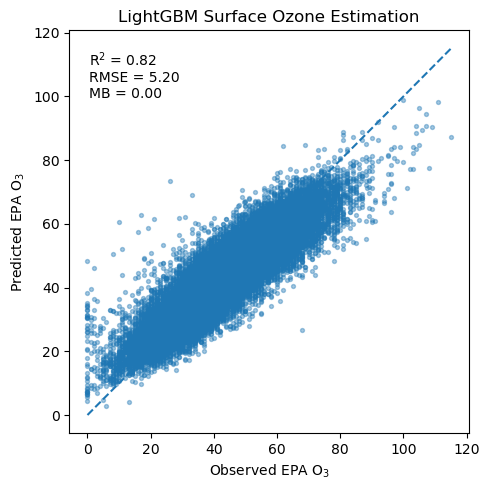

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_lgbm, s=8, alpha=0.4)

min_val = min(y_test.min(), y_pred_lgbm.min())
max_val = max(y_test.max(), y_pred_lgbm.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed EPA O$_3$")
plt.ylabel("Predicted EPA O$_3$")
plt.title("LightGBM Surface Ozone Estimation")

plt.text(
    0.05, 0.95,
    f"R$^2$ = {r2_lgbm:.2f}\nRMSE = {rmse_lgbm:.2f}\nMB = {mb_lgbm:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()